# Relative sensory-feedback importance

Saliency-analysis method of Yu et al., *"Identifying Important Sensory Feedback
for Learning Locomotion Skills,"* Nature Machine Intelligence (2023)
[[arXiv:2306.17101]](https://arxiv.org/abs/2306.17101).

**Method**: integrated gradients w.r.t. a zero baseline, summed as abs value
across all 19 action outputs, then grouped into the 5 sensor modalities
(pos/vel/action/imu/fc) and normalized so the group importances sum to 100%:
$r_o = I_o / \sum_o I_o$.

Uses the **real, precomputed IG results** in `integrate_grad/ig/STUDENT-dagger-{0..9}-ig/ig_summary.json`
— one run per independently-trained "flat" DAgger student, each computed on
that student's own **on-policy** rollout states (not a proxy):

| setting | value |
|---|---|
| baseline | zeros |
| integration steps | 64 |
| output reduction | abs_sum over the 19 action outputs |
| states | 20,000 on-policy states per student (from its own distillation buffer) |
| completeness error | ~4e-4 to 9e-4 |

`group_importance_pct` in each summary is already the per-policy $r_o$ (%), so
this notebook just pools the 10 policies and plots bar = mean, dots =
individual policies.


In [1]:
import json
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt


In [2]:
# Paths are relative to this notebook's own directory (integrate_grad/).
IG_DIR = Path("ig")
TERRAIN = "flat"
GROUP_ORDER = ["pos", "vel", "action", "imu", "fc"]


def load_group_importance(ig_dir, terrain):
    summary = json.loads((ig_dir / "ig_summary.json").read_text())
    pct = summary["terrains"][terrain]["group_importance_pct"]
    return np.array([pct[g] for g in GROUP_ORDER]) / 100.0  # -> fractions, sums to 1


In [3]:
policy_dirs = sorted(IG_DIR.glob("STUDENT-dagger-*-ig"), key=lambda p: int(p.name.split("-")[2]))

results = []  # list of (policy_name, r_o array)
for pdir in policy_dirs:
    summary_path = pdir / "ig_summary.json"
    if not summary_path.exists():
        continue
    r_o = load_group_importance(pdir, TERRAIN)
    results.append((pdir.name, r_o))
    print(f"{pdir.name}: " + ", ".join(f"{g}={v*100:.1f}%" for g, v in zip(GROUP_ORDER, r_o)))

R = np.stack([r for _, r in results], axis=0)  # (num_policies, 5)
np.save("relative_importance.npy", R)
with open("relative_importance_meta.json", "w") as f:
    json.dump({"group_order": GROUP_ORDER, "policies": [n for n, _ in results],
                "terrain": TERRAIN, "source": "real IG (ig_summary.json, on-policy states)"}, f, indent=2)
print(f"\nSaved {R.shape} array -> relative_importance.npy")


STUDENT-dagger-0-ig: pos=18.5%, vel=33.1%, action=39.5%, imu=0.7%, fc=8.2%
STUDENT-dagger-1-ig: pos=18.5%, vel=35.0%, action=37.7%, imu=0.7%, fc=8.2%
STUDENT-dagger-2-ig: pos=17.8%, vel=34.8%, action=37.8%, imu=0.9%, fc=8.7%
STUDENT-dagger-3-ig: pos=18.6%, vel=35.3%, action=37.9%, imu=0.7%, fc=7.5%
STUDENT-dagger-4-ig: pos=19.5%, vel=34.7%, action=37.4%, imu=0.6%, fc=7.8%
STUDENT-dagger-5-ig: pos=19.7%, vel=34.9%, action=36.9%, imu=0.7%, fc=7.9%
STUDENT-dagger-6-ig: pos=18.4%, vel=34.6%, action=37.8%, imu=0.8%, fc=8.4%
STUDENT-dagger-7-ig: pos=17.9%, vel=34.8%, action=38.2%, imu=0.6%, fc=8.5%
STUDENT-dagger-8-ig: pos=18.5%, vel=33.6%, action=39.2%, imu=0.6%, fc=8.1%
STUDENT-dagger-9-ig: pos=18.6%, vel=34.7%, action=37.4%, imu=0.6%, fc=8.6%

Saved (10, 5) array -> relative_importance.npy


## Plot — bar (mean across policies) + scatter (individual policies)

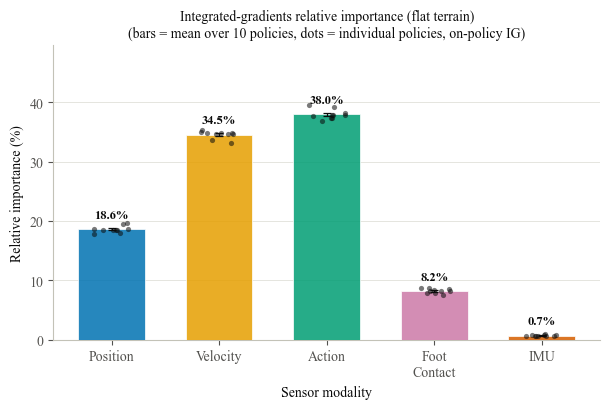

Mean relative importance (%):
  pos      18.60 +/- 0.19 (SEM)
  vel      34.54 +/- 0.21 (SEM)
  action   37.99 +/- 0.26 (SEM)
  fc        8.19 +/- 0.12 (SEM)
  imu       0.68 +/- 0.03 (SEM)


In [4]:
# House style matching the other analysis notebooks in this repo (serif fonts,
# CVD-safe categorical colours, light dashed y-grid).
INK, INK2, GRID = '#0b0b0b', '#52514e', '#e1e0d9'
PLOT_ORDER = ["pos", "vel", "action", "fc", "imu"]
GROUP_COLOR = {"pos": "#0072B2", "vel": "#E69F00", "action": "#009E73",
               "fc": "#CC79A7", "imu": "#D55E00"}
PLOT_LABEL = {"pos": "Position", "vel": "Velocity", "action": "Action",
              "fc": "Foot\nContact", "imu": "IMU"}

plt.rcParams.update({
    'font.family': 'serif', 'font.serif': ['Times New Roman', 'DejaVu Serif'],
    'axes.edgecolor': '#c3c2b7', 'text.color': INK, 'axes.labelcolor': INK,
    'xtick.color': INK2, 'ytick.color': INK2,
})

col_idx = {g: GROUP_ORDER.index(g) for g in PLOT_ORDER}
R_pct = R * 100.0
means = np.array([R_pct[:, col_idx[g]].mean() for g in PLOT_ORDER])
sems = np.array([R_pct[:, col_idx[g]].std(ddof=1) / np.sqrt(R_pct.shape[0]) for g in PLOT_ORDER])

fig, ax = plt.subplots(figsize=(6.2, 4.2))
x = np.arange(len(PLOT_ORDER))
W = 0.62
ax.bar(x, means, width=W, color=[GROUP_COLOR[g] for g in PLOT_ORDER], alpha=0.85,
       edgecolor="white", linewidth=0.6, zorder=3)
ax.errorbar(x, means, yerr=sems, fmt="none", ecolor=INK, elinewidth=0.9,
            capsize=3, capthick=0.9, zorder=5)

rng = np.random.default_rng(0)
for i, g in enumerate(PLOT_ORDER):
    vals = R_pct[:, col_idx[g]]
    jitter = rng.uniform(-W * 0.28, W * 0.28, size=vals.size)
    ax.scatter(x[i] + jitter, vals, s=14, color=INK, alpha=0.55, linewidths=0, zorder=4)

for xi, m in zip(x, means):
    ax.annotate(f"{m:.1f}%", (xi, m), xytext=(0, 6), textcoords="offset points",
                ha="center", va="bottom", fontsize=9, fontweight="bold")

ax.set_xticks(x)
ax.set_xticklabels([PLOT_LABEL[g] for g in PLOT_ORDER], fontsize=10)
ax.set_ylabel("Relative importance (%)", fontsize=10)
ax.set_xlabel("Sensor modality", fontsize=10)
ax.set_ylim(0, max(means + sems) * 1.3)
ax.set_title(f"Integrated-gradients relative importance ({TERRAIN} terrain)\n"
             f"(bars = mean over {R.shape[0]} policies, dots = individual policies, on-policy IG)",
             fontsize=10)
ax.grid(True, axis='y', color=GRID, lw=0.6); ax.set_axisbelow(True)
for sp in ('top', 'right'):
    ax.spines[sp].set_visible(False)

fig.tight_layout()
fig.savefig("relative_importance_ig.png", dpi=300, bbox_inches="tight")
plt.show()

print("Mean relative importance (%):")
for g, m, s in zip(PLOT_ORDER, means, sems):
    print(f"  {g:<8} {m:5.2f} +/- {s:.2f} (SEM)")
